# Sentiment Analysis of Movie Reviews using RNN, LSTM, and Word2Vec Embeddings


## 1. Install Dependencies and Import Libraries

In [1]:
# Install required libraries
# Install gensim compatible numpy version first, then reinstall gensim
!pip install numpy==1.24.3 --quiet
!pip install gensim --quiet
!pip install nltk --quiet
!pip install wordcloud --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 40.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 84.6 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import time
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, SimpleRNN, LSTM,
                                     Dense, Dropout, Bidirectional)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

# Download NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print('TensorFlow version:', tf.__version__)
print('All libraries imported successfully.')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


TensorFlow version: 2.20.0
All libraries imported successfully.


## 2. Mount Google Drive and Load Dataset

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import zipfile
import os

# Path to the zip file
zip_path = '/content/drive/MyDrive/AI and Machine Learning/Language task /5. Movie Review Dataset-20260423T065936Z-3-001.zip'
extract_path = '/content/movie_dataset/'

# Extract the zip file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print('Files extracted:')
for root, dirs, files in os.walk(extract_path):
    for f in files:
        print(' ', os.path.join(root, f))

Files extracted:
  /content/movie_dataset/5. Movie Review Dataset/val_movie_review.csv
  /content/movie_dataset/5. Movie Review Dataset/train_movie_review.csv
  /content/movie_dataset/5. Movie Review Dataset/5.Description Movie Review Dataset.txt
  /content/movie_dataset/5. Movie Review Dataset/test_movie_review.csv


In [7]:
# Load the three splits
base_path = '/content/movie_dataset/5. Movie Review Dataset/'

train_df = pd.read_csv(base_path + 'train_movie_review.csv')
val_df   = pd.read_csv(base_path + 'val_movie_review.csv')
test_df  = pd.read_csv(base_path + 'test_movie_review.csv')

# Drop index column
train_df = train_df[['review', 'sentiment']]
val_df   = val_df[['review', 'sentiment']]
test_df  = test_df[['review', 'sentiment']]

print('Train shape:', train_df.shape)
print('Val shape  :', val_df.shape)
print('Test shape :', test_df.shape)
print('\nColumns:', train_df.columns.tolist())
print('\nSample data:')
train_df.head(3)

Train shape: (35000, 2)
Val shape  : (5000, 2)
Test shape : (10000, 2)

Columns: ['review', 'sentiment']

Sample data:


,review,sentiment
0,"Having avoided seeing the movie in the cinema,...",0
1,With this movie I was really hoping that the i...,0
2,Raymond Burr stars as an attorney caught up in...,0


## 3. Data Understanding and Analysis

### 3.1 Dataset Overview

In [8]:
print('=== DATASET OVERVIEW ===')
print(f'Total samples  : {len(train_df) + len(val_df) + len(test_df)}')
print(f'Training set   : {len(train_df)} reviews')
print(f'Validation set : {len(val_df)} reviews')
print(f'Test set       : {len(test_df)} reviews')
print('\nLabel encoding: 0 = Negative, 1 = Positive')
print('\nNull values in train:')
print(train_df.isnull().sum())
print('\nClass distribution in training set:')
print(train_df['sentiment'].value_counts())

=== DATASET OVERVIEW ===
Total samples  : 50000
Training set   : 35000 reviews
Validation set : 5000 reviews
Test set       : 10000 reviews

Label encoding: 0 = Negative, 1 = Positive

Null values in train:
review       0
sentiment    0
dtype: int64

Class distribution in training set:
sentiment
0    17584
1    17416
Name: count, dtype: int64


### 3.2 Class Distribution Visualization

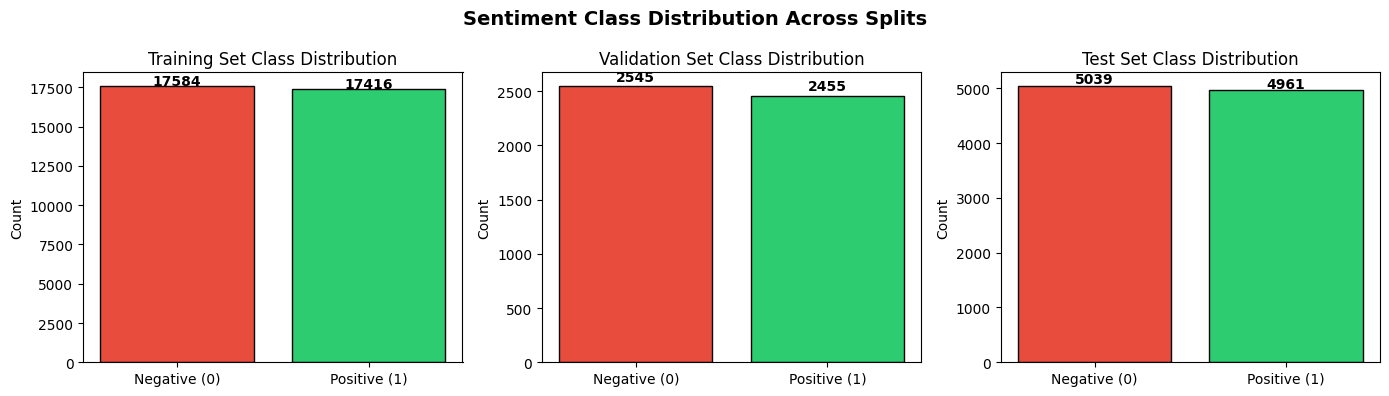

The dataset is well-balanced across all splits.


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
splits = [('Training', train_df), ('Validation', val_df), ('Test', test_df)]

for ax, (name, df) in zip(axes, splits):
    counts = df['sentiment'].value_counts()
    ax.bar(['Negative (0)', 'Positive (1)'], counts.values,
           color=['#e74c3c', '#2ecc71'], edgecolor='black')
    ax.set_title(f'{name} Set Class Distribution')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.suptitle('Sentiment Class Distribution Across Splits', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('The dataset is well-balanced across all splits.')

### 3.3 Review Length Analysis

Review word count statistics (Training set):
  Min     : 4
  Max     : 2470
  Mean    : 230.7
  Median  : 173.0
  90th %  : 449
  95th %  : 587


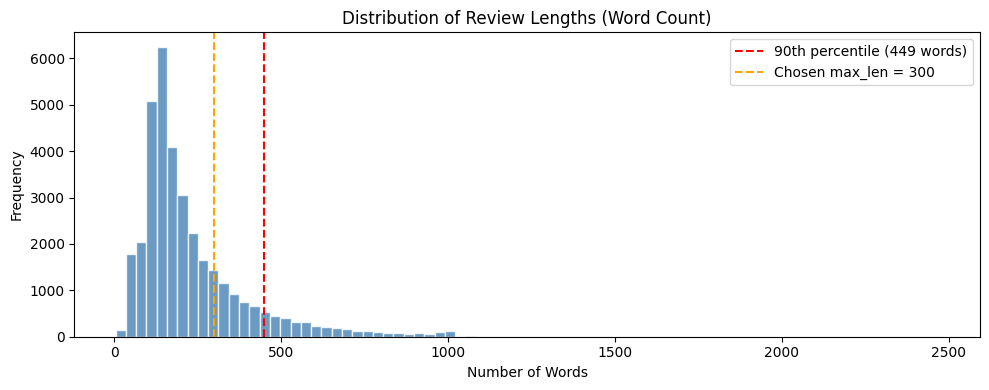

In [10]:
train_lengths = train_df['review'].str.split().str.len()

print('Review word count statistics (Training set):')
print(f'  Min     : {train_lengths.min()}')
print(f'  Max     : {train_lengths.max()}')
print(f'  Mean    : {train_lengths.mean():.1f}')
print(f'  Median  : {train_lengths.median():.1f}')
print(f'  90th %  : {np.percentile(train_lengths, 90):.0f}')
print(f'  95th %  : {np.percentile(train_lengths, 95):.0f}')

plt.figure(figsize=(10, 4))
plt.hist(train_lengths, bins=80, color='steelblue', edgecolor='white', alpha=0.8)
plt.axvline(np.percentile(train_lengths, 90), color='red',
            linestyle='--', label=f'90th percentile ({np.percentile(train_lengths,90):.0f} words)')
plt.axvline(300, color='orange',
            linestyle='--', label='Chosen max_len = 300')
plt.title('Distribution of Review Lengths (Word Count)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

### 3.4 Word Cloud Visualization

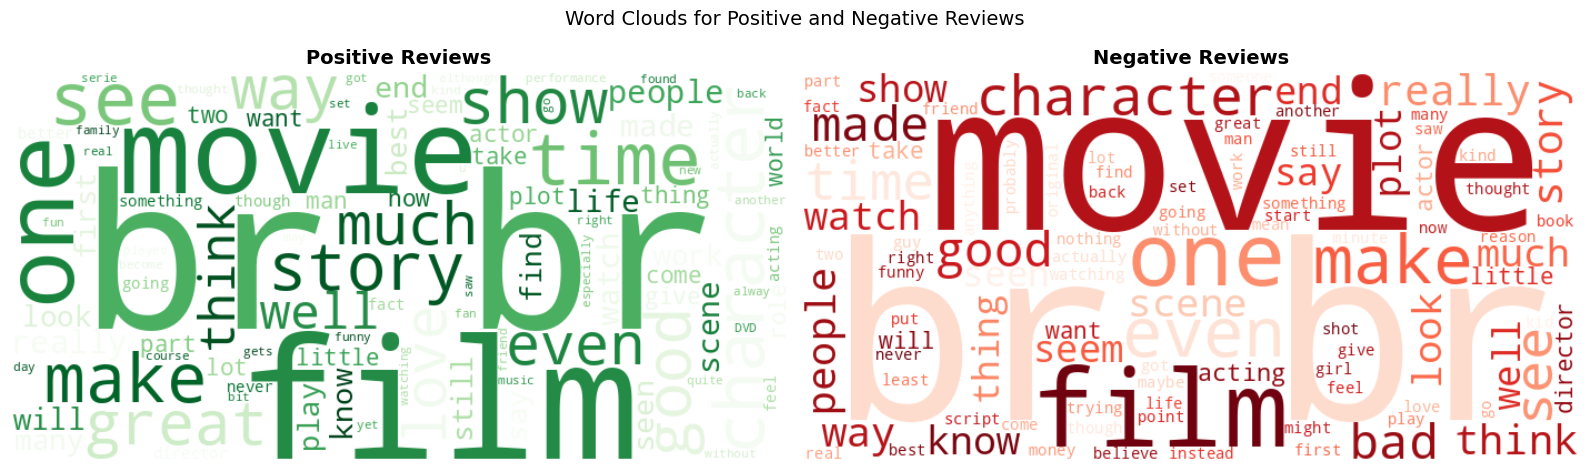

In [11]:
# Word cloud for positive reviews
pos_text = ' '.join(train_df[train_df['sentiment'] == 1]['review'].values)
neg_text = ' '.join(train_df[train_df['sentiment'] == 0]['review'].values)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, text, title, color in zip(
        axes,
        [pos_text, neg_text],
        ['Positive Reviews', 'Negative Reviews'],
        ['Greens', 'Reds']):
    wc = WordCloud(width=700, height=350, background_color='white',
                   colormap=color, max_words=100).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=14, fontweight='bold')

plt.suptitle('Word Clouds for Positive and Negative Reviews', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Text Preprocessing

### 4.1 Text Cleaning

The following preprocessing steps are applied:
- Lowercase all text
- Remove HTML tags (common in IMDb reviews)
- Remove URLs, mentions, hashtags, numbers, and special characters
- Handle contractions
- Remove stopwords
- Lemmatize words to their base form

In [13]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Contractions dictionary
contractions = {
    "don't": "do not", "doesn't": "does not", "didn't": "did not",
    "won't": "will not", "wouldn't": "would not", "couldn't": "could not",
    "shouldn't": "should not", "isn't": "is not", "aren't": "are not",
    "wasn't": "was not", "weren't": "were not", "haven't": "have not",
    "hasn't": "has not", "hadn't": "had not", "it's": "it is",
    "i'm": "i am", "i've": "i have", "i'll": "i will",
    "i'd": "i would", "you're": "you are", "they're": "they are",
    "we're": "we are", "that's": "that is", "there's": "there is",
    "can't": "cannot", "let's": "let us"
}

def clean_text(text):
    # Lowercase
    text = text.lower()
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)
    # Expand contractions
    for contraction, expansion in contractions.items():
        text = text.replace(contraction, expansion)
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)
    # Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', ' ', text)
    # Remove numbers
    text = re.sub(r'\d+', ' ', text)
    # Remove special characters and punctuation
    text = re.sub(r'[^a-z\s]', ' ', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # Tokenize, remove stopwords, lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 1]
    return ' '.join(tokens)

print('Cleaning training set...')
t0 = time.time()
train_df['cleaned'] = train_df['review'].apply(clean_text)
print(f'Train cleaned in {time.time()-t0:.1f}s')

print('Cleaning validation set...')
val_df['cleaned'] = val_df['review'].apply(clean_text)

print('Cleaning test set...')
test_df['cleaned'] = test_df['review'].apply(clean_text)

print('\nExample - Original:')
print(train_df['review'].iloc[0][:200])
print('\nExample - Cleaned:')
print(train_df['cleaned'].iloc[0][:200])

Cleaning training set...
Train cleaned in 26.1s
Cleaning validation set...
Cleaning test set...

Example - Original:
Having avoided seeing the movie in the cinema, but buying the DVD for my wife for Xmas, I had to watch it. I did not expect much, which usually means I get more than I bargained for. But 'Mamma Mia' -

Example - Cleaned:
avoided seeing movie cinema buying dvd wife xmas watch expect much usually mean get bargained mamma mia utter utter cr like abba like song old lp film terrible stage show look like bit musical race al


### 4.2 Most Frequent Words After Cleaning

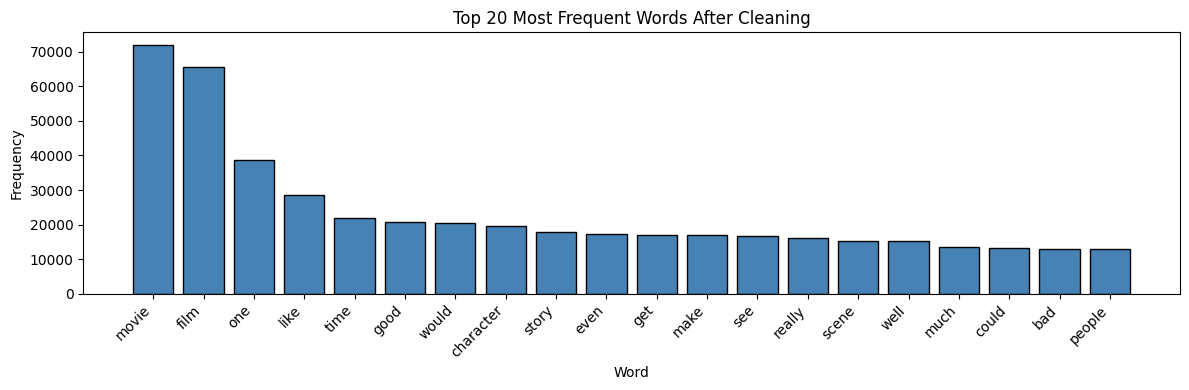

In [14]:
from collections import Counter

all_words = ' '.join(train_df['cleaned']).split()
word_freq = Counter(all_words).most_common(20)

words, counts = zip(*word_freq)
plt.figure(figsize=(12, 4))
plt.bar(words, counts, color='steelblue', edgecolor='black')
plt.title('Top 20 Most Frequent Words After Cleaning')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 4.3 Tokenization and Sequence Padding

In [15]:
# Hyperparameters
VOCAB_SIZE  = 20000   # Top 20k most frequent words
MAX_LEN     = 300     # Based on 90th percentile analysis (~449 words)
EMBEDDING_DIM = 50    # Matches GloVe 50d

# Fit tokenizer on training data only
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(train_df['cleaned'])

word_index = tokenizer.word_index
print(f'Vocabulary size (unique words): {len(word_index)}')
print(f'Using top {VOCAB_SIZE} words')
print(f'Max sequence length: {MAX_LEN}')

# Convert text to sequences
X_train = tokenizer.texts_to_sequences(train_df['cleaned'])
X_val   = tokenizer.texts_to_sequences(val_df['cleaned'])
X_test  = tokenizer.texts_to_sequences(test_df['cleaned'])

# Apply padding (post-padding, truncate long sequences)
X_train = pad_sequences(X_train, maxlen=MAX_LEN, padding='post', truncating='post')
X_val   = pad_sequences(X_val,   maxlen=MAX_LEN, padding='post', truncating='post')
X_test  = pad_sequences(X_test,  maxlen=MAX_LEN, padding='post', truncating='post')

y_train = train_df['sentiment'].values
y_val   = val_df['sentiment'].values
y_test  = test_df['sentiment'].values

print(f'\nX_train shape : {X_train.shape}')
print(f'X_val shape   : {X_val.shape}')
print(f'X_test shape  : {X_test.shape}')
print(f'y_train shape : {y_train.shape}')

Vocabulary size (unique words): 77165
Using top 20000 words
Max sequence length: 300

X_train shape : (35000, 300)
X_val shape   : (5000, 300)
X_test shape  : (10000, 300)
y_train shape : (35000,)


## 5. Model 1: Simple RNN with Trainable Embedding

A basic SimpleRNN model with a trainable embedding layer. This serves as the baseline recurrent model.

In [16]:
# Build Simple RNN Model
rnn_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    SimpleRNN(64, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
], name='SimpleRNN_Model')

rnn_model.summary()

Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:
rnn_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=3,
                           restore_best_weights=True, verbose=1)

print('Training Simple RNN Model...')
t0 = time.time()
rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)
rnn_training_time = time.time() - t0
print(f'\nRNN Training Time: {rnn_training_time:.2f} seconds')

Training Simple RNN Model...
Epoch 1/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.5018 - loss: 0.6986 - val_accuracy: 0.5020 - val_loss: 0.6935
Epoch 2/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.4973 - loss: 0.6973 - val_accuracy: 0.4960 - val_loss: 0.6937
Epoch 3/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.5053 - loss: 0.6953 - val_accuracy: 0.5110 - val_loss: 0.6933
Epoch 4/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.5035 - loss: 0.6952 - val_accuracy: 0.4930 - val_loss: 0.6935
Epoch 5/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.5023 - loss: 0.6939 - val_accuracy: 0.5074 - val_loss: 0.6930
Epoch 6/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.5062 - loss: 0.6931 - val_accuracy: 0.4942 - val_loss: 0.6936
Epoch 7/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.5047 - loss: 0.6929 - val_accuracy: 0.4960 - val_loss: 0.6933
Epoch 8/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 

### 5.1 Simple RNN Training Plots

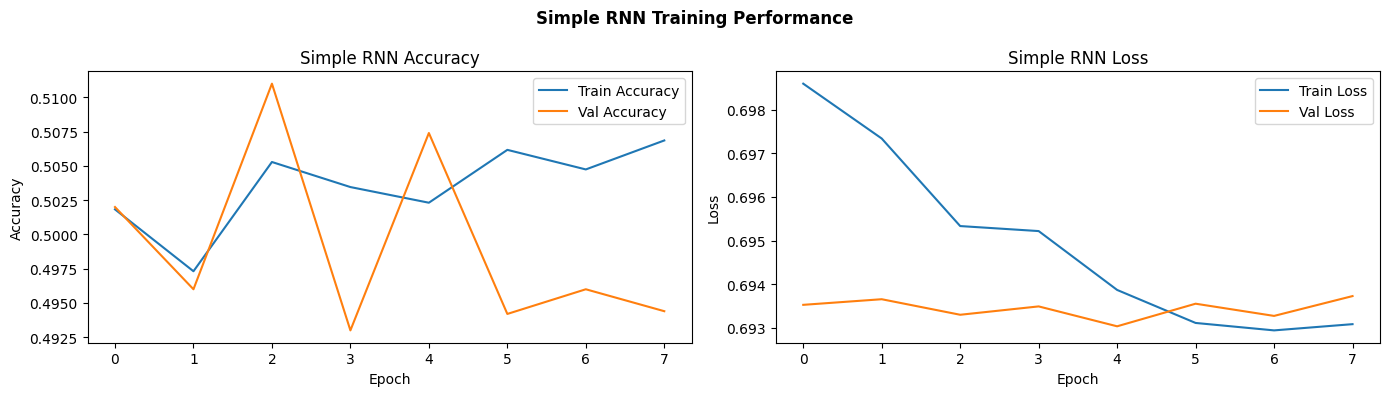

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(rnn_history.history['accuracy'], label='Train Accuracy')
axes[0].plot(rnn_history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Simple RNN Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(rnn_history.history['loss'], label='Train Loss')
axes[1].plot(rnn_history.history['val_loss'], label='Val Loss')
axes[1].set_title('Simple RNN Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('Simple RNN Training Performance', fontweight='bold')
plt.tight_layout()
plt.show()

### 5.2 Simple RNN Evaluation

=== Simple RNN Model Evaluation ===
Test Accuracy: 0.5040

Classification Report:
              precision    recall  f1-score   support

    Negative       0.51      0.01      0.01      4961
    Positive       0.50      0.99      0.67      5039

    accuracy                           0.50     10000
   macro avg       0.51      0.50      0.34     10000
weighted avg       0.51      0.50      0.34     10000



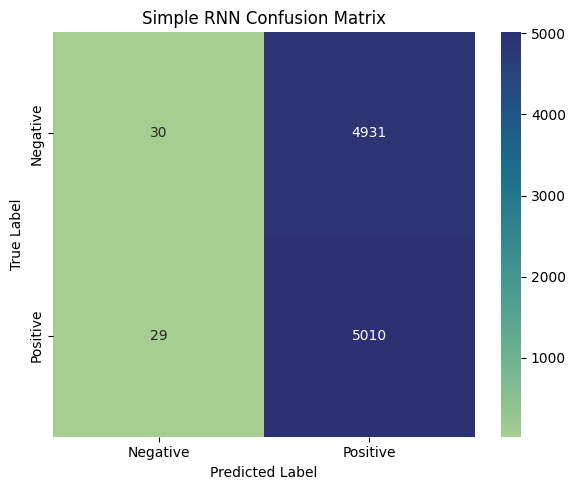

In [24]:
rnn_preds_prob = rnn_model.predict(X_test, verbose=0)
rnn_preds = (rnn_preds_prob > 0.5).astype(int).flatten()

print('=== Simple RNN Model Evaluation ===')
print(f'Test Accuracy: {accuracy_score(y_test, rnn_preds):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, rnn_preds,
                            target_names=['Negative', 'Positive']))

cm = confusion_matrix(y_test, rnn_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='crest',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Simple RNN Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

## 6. Model 2: LSTM with Trainable Embedding

LSTM overcomes the vanishing gradient problem of SimpleRNN using gating mechanisms that allow it to retain long-range dependencies in text.

In [25]:
# Build LSTM Model
lstm_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
], name='LSTM_Model')

lstm_model.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [26]:
lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=3,
                           restore_best_weights=True, verbose=1)

print('Training LSTM Model...')
t0 = time.time()
lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)
lstm_training_time = time.time() - t0
print(f'\nLSTM Training Time: {lstm_training_time:.2f} seconds')

Training LSTM Model...
Epoch 1/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - accuracy: 0.5047 - loss: 0.6933 - val_accuracy: 0.4978 - val_loss: 0.6931
Epoch 2/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.5152 - loss: 0.6895 - val_accuracy: 0.5044 - val_loss: 0.6903
Epoch 3/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.5238 - loss: 0.6757 - val_accuracy: 0.5042 - val_loss: 0.6941
Epoch 4/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.5279 - loss: 0.6647 - val_accuracy: 0.5076 - val_loss: 0.7018
Epoch 5/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.5638 - loss: 0.6511 - val_accuracy: 0.7184 - val_loss: 0.6284
Epoch 6/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - accuracy: 0.7281 - loss: 0.5748 - val_accuracy: 0.7124 - val_loss: 0.6270
Epoch 7/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.5984 - loss: 0.6472 - val_accuracy: 0.5054 - val_loss: 0.6993
Epoch 8/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.5408 

### 6.1 LSTM Training Plots

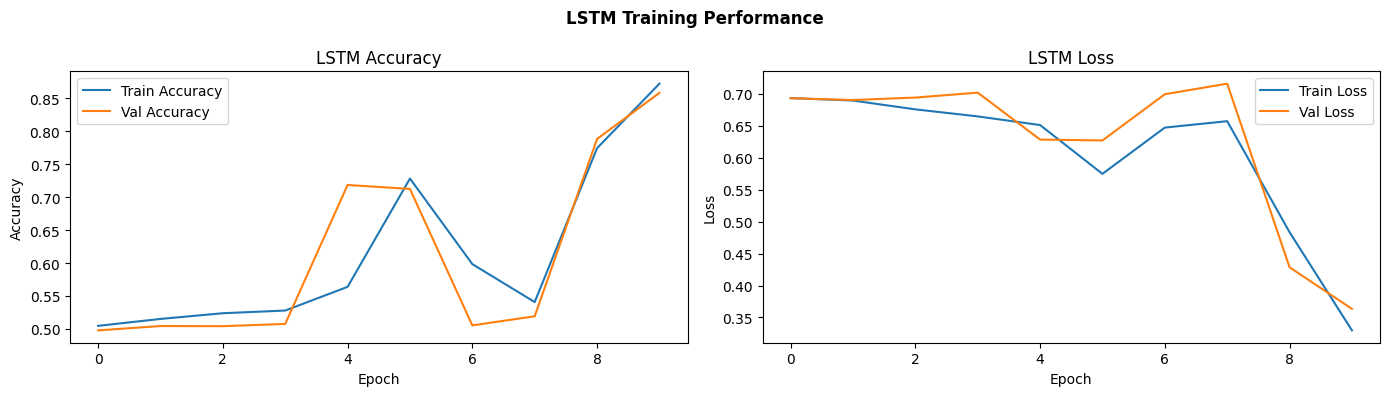

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(lstm_history.history['accuracy'], label='Train Accuracy')
axes[0].plot(lstm_history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('LSTM Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(lstm_history.history['loss'], label='Train Loss')
axes[1].plot(lstm_history.history['val_loss'], label='Val Loss')
axes[1].set_title('LSTM Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('LSTM Training Performance', fontweight='bold')
plt.tight_layout()
plt.show()

### 6.2 LSTM Evaluation

=== LSTM Model Evaluation ===
Test Accuracy: 0.8628

Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.83      0.86      4961
    Positive       0.84      0.90      0.87      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



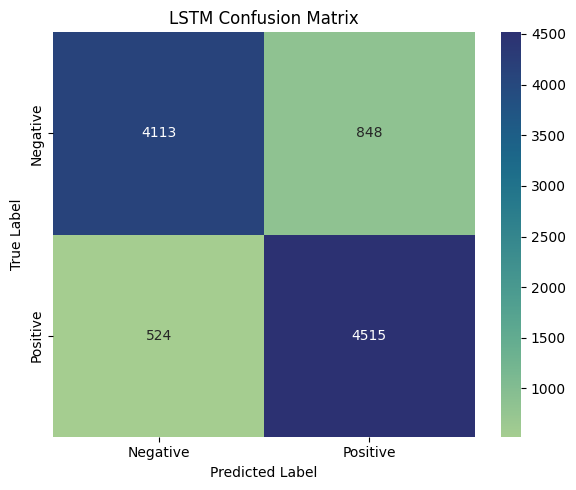

In [31]:
lstm_preds_prob = lstm_model.predict(X_test, verbose=0)
lstm_preds = (lstm_preds_prob > 0.5).astype(int).flatten()

print('=== LSTM Model Evaluation ===')
print(f'Test Accuracy: {accuracy_score(y_test, lstm_preds):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, lstm_preds,
                            target_names=['Negative', 'Positive']))

cm = confusion_matrix(y_test, lstm_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='crest',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('LSTM Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

## 7. Model 3: LSTM with Pre-trained Word2Vec (GloVe) Embeddings

Pre-trained GloVe embeddings (glove-wiki-gigaword-50) are used to initialise the embedding layer. The embeddings are frozen so the model benefits from rich, pre-learned word representations without overfitting.

In [32]:
import gensim.downloader as api

print('Loading pre-trained GloVe embeddings (glove-wiki-gigaword-50)...')
print('This may take a few minutes on first run...')
embedding_model = api.load('glove-wiki-gigaword-50')
print(f'GloVe model loaded. Vocabulary size: {len(embedding_model.key_to_index)}')

Loading pre-trained GloVe embeddings (glove-wiki-gigaword-50)...
This may take a few minutes on first run...
[==================================================] 100.0% 66.0/66.0MB downloaded
GloVe model loaded. Vocabulary size: 400000


In [33]:
# Build embedding matrix
embedding_matrix = np.zeros((VOCAB_SIZE, EMBEDDING_DIM))
found = 0

for word, idx in word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if word in embedding_model:
        embedding_matrix[idx] = embedding_model[word]
        found += 1

coverage = found / min(len(word_index), VOCAB_SIZE) * 100
print(f'Words found in GloVe: {found}/{min(len(word_index), VOCAB_SIZE)} ({coverage:.1f}% coverage)')

Words found in GloVe: 19834/20000 (99.2% coverage)


In [34]:
# Build LSTM Model with pre-trained GloVe embeddings
lstm_glove_model = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=False  # Freeze pre-trained weights
    ),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
], name='LSTM_GloVe_Model')

lstm_glove_model.summary()

Model: "LSTM_GloVe_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

In [35]:
lstm_glove_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=3,
                           restore_best_weights=True, verbose=1)

print('Training LSTM + GloVe Model...')
t0 = time.time()
lstm_glove_history = lstm_glove_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)
lstm_glove_training_time = time.time() - t0
print(f'\nLSTM + GloVe Training Time: {lstm_glove_training_time:.2f} seconds')

Training LSTM + GloVe Model...
Epoch 1/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.5124 - loss: 0.6940 - val_accuracy: 0.4912 - val_loss: 0.6919
Epoch 2/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.5428 - loss: 0.6796 - val_accuracy: 0.6286 - val_loss: 0.6596
Epoch 3/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.5250 - loss: 0.6870 - val_accuracy: 0.4910 - val_loss: 0.6905
Epoch 4/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.4998 - loss: 0.6908 - val_accuracy: 0.5176 - val_loss: 0.6884
Epoch 5/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 17s 29ms/step - accuracy: 0.5045 - loss: 0.6899 - val_accuracy: 0.4912 - val_loss: 0.6887
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.

LSTM + GloVe Training Time: 56.42 seconds


### 7.1 LSTM + GloVe Training Plots

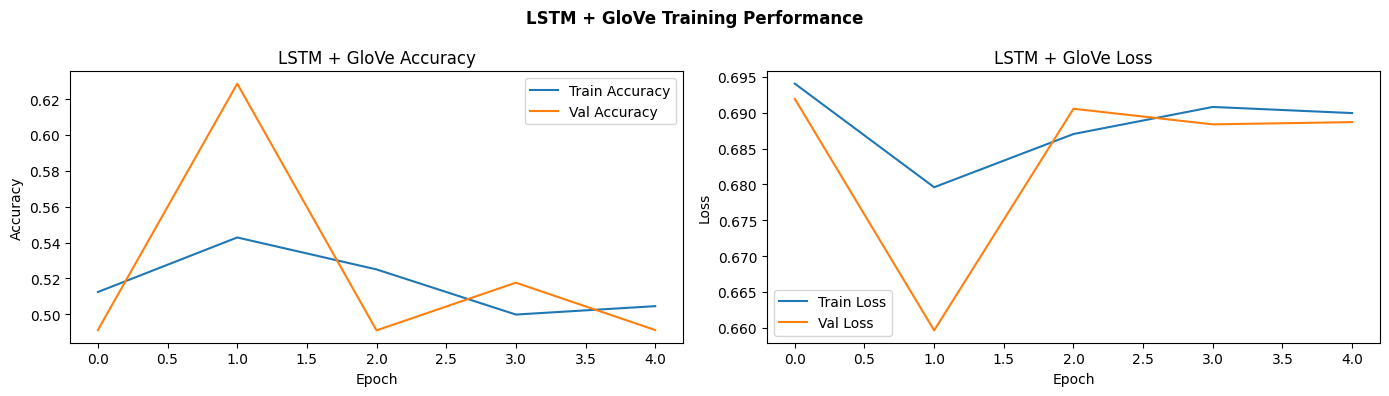

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(lstm_glove_history.history['accuracy'], label='Train Accuracy')
axes[0].plot(lstm_glove_history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('LSTM + GloVe Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(lstm_glove_history.history['loss'], label='Train Loss')
axes[1].plot(lstm_glove_history.history['val_loss'], label='Val Loss')
axes[1].set_title('LSTM + GloVe Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('LSTM + GloVe Training Performance', fontweight='bold')
plt.tight_layout()
plt.show()

### 7.2 LSTM + GloVe Evaluation

=== LSTM + GloVe Model Evaluation ===
Test Accuracy: 0.6309

Classification Report:
              precision    recall  f1-score   support

    Negative       0.66      0.54      0.59      4961
    Positive       0.61      0.72      0.66      5039

    accuracy                           0.63     10000
   macro avg       0.63      0.63      0.63     10000
weighted avg       0.63      0.63      0.63     10000



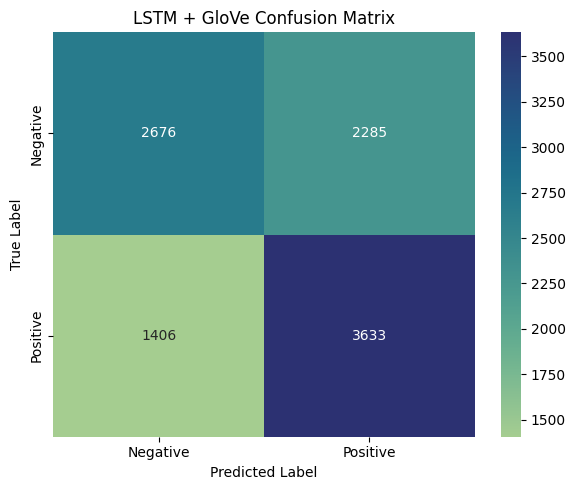

In [37]:
lstm_glove_preds_prob = lstm_glove_model.predict(X_test, verbose=0)
lstm_glove_preds = (lstm_glove_preds_prob > 0.5).astype(int).flatten()

print('=== LSTM + GloVe Model Evaluation ===')
print(f'Test Accuracy: {accuracy_score(y_test, lstm_glove_preds):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, lstm_glove_preds,
                            target_names=['Negative', 'Positive']))

cm = confusion_matrix(y_test, lstm_glove_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='crest',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('LSTM + GloVe Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

## 8. Model Comparison

       Model  Test Accuracy  Training Time (s)
  Simple RNN         0.5040          69.522129
        LSTM         0.8628          94.857382
LSTM + GloVe         0.6309          56.416215


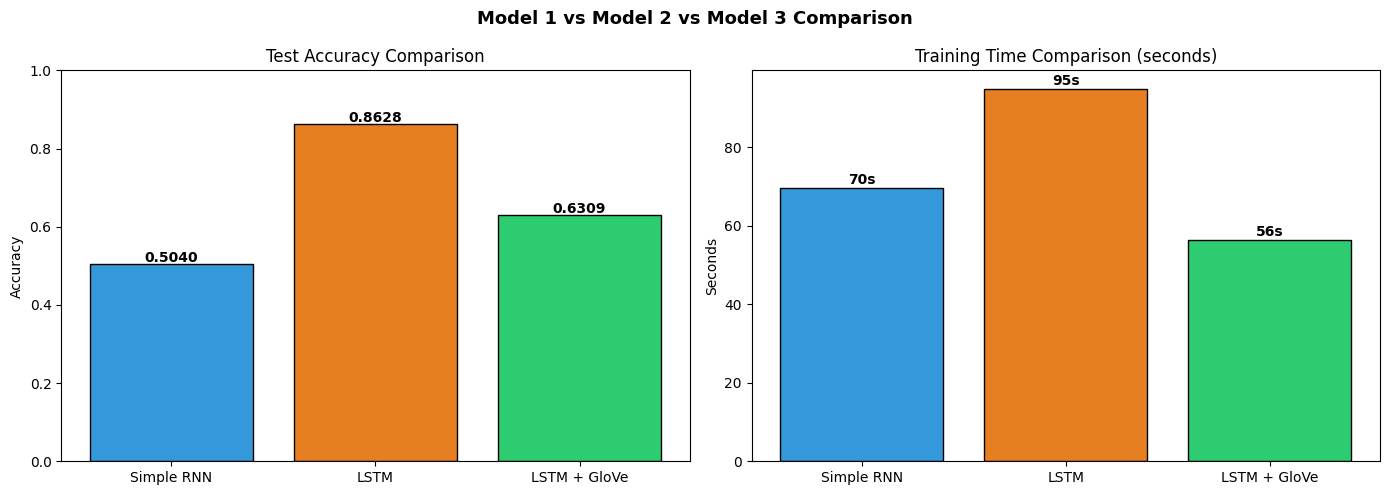

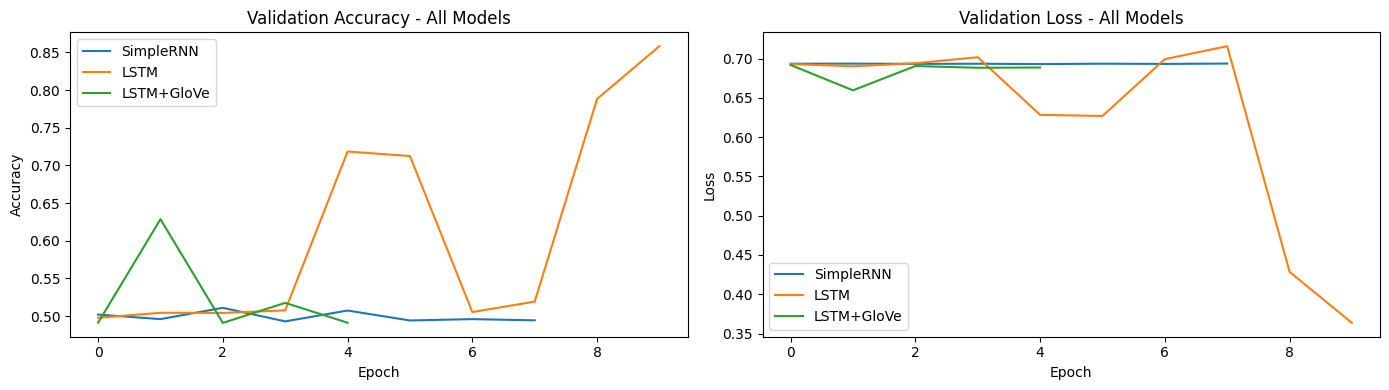

In [38]:
# Collect all results
rnn_acc   = accuracy_score(y_test, rnn_preds)
lstm_acc  = accuracy_score(y_test, lstm_preds)
glove_acc = accuracy_score(y_test, lstm_glove_preds)

results = pd.DataFrame({
    'Model'         : ['Simple RNN', 'LSTM', 'LSTM + GloVe'],
    'Test Accuracy' : [rnn_acc, lstm_acc, glove_acc],
    'Training Time (s)': [rnn_training_time, lstm_training_time, lstm_glove_training_time]
})
print(results.to_string(index=False))

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#3498db', '#e67e22', '#2ecc71']

axes[0].bar(results['Model'], results['Test Accuracy'], color=colors, edgecolor='black')
axes[0].set_title('Test Accuracy Comparison')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1)
for i, v in enumerate(results['Test Accuracy']):
    axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

axes[1].bar(results['Model'], results['Training Time (s)'], color=colors, edgecolor='black')
axes[1].set_title('Training Time Comparison (seconds)')
axes[1].set_ylabel('Seconds')
for i, v in enumerate(results['Training Time (s)']):
    axes[1].text(i, v + 1, f'{v:.0f}s', ha='center', fontweight='bold')

plt.suptitle('Model 1 vs Model 2 vs Model 3 Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Overlay training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for hist, label in [(rnn_history, 'SimpleRNN'),
                    (lstm_history, 'LSTM'),
                    (lstm_glove_history, 'LSTM+GloVe')]:
    axes[0].plot(hist.history['val_accuracy'], label=label)
    axes[1].plot(hist.history['val_loss'], label=label)

axes[0].set_title('Validation Accuracy - All Models')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].set_title('Validation Loss - All Models')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Error Analysis

Analysing misclassified examples from the best performing model (LSTM + GloVe) to understand where the model struggles.

In [39]:
# Get misclassified samples from LSTM+GloVe model
test_reviews_original = test_df['review'].values
misclassified_idx = np.where(lstm_glove_preds != y_test)[0]

print(f'Total misclassified: {len(misclassified_idx)} / {len(y_test)}')
print(f'Error rate: {len(misclassified_idx)/len(y_test)*100:.2f}%\n')

label_map = {0: 'Negative', 1: 'Positive'}

print('=== 3 MISCLASSIFIED EXAMPLES ===')
for i, idx in enumerate(misclassified_idx[:3]):
    print(f'\nExample {i+1}:')
    print(f'  True Label      : {label_map[y_test[idx]]}')
    print(f'  Predicted Label : {label_map[lstm_glove_preds[idx]]}')
    print(f'  Confidence      : {lstm_glove_preds_prob[idx][0]:.4f}')
    print(f'  Review (first 200 chars): {test_reviews_original[idx][:200]}')
    print('-' * 70)

Total misclassified: 3691 / 10000
Error rate: 36.91%

=== 3 MISCLASSIFIED EXAMPLES ===

Example 1:
  True Label      : Positive
  Predicted Label : Negative
  Confidence      : 0.3749
  Review (first 200 chars): Not many television shows appeal to quite as many different kinds of fans like Farscape does...I know youngsters and 30/40+ years old;fans both Male and Female in as many different countries as you ca
----------------------------------------------------------------------

Example 2:
  True Label      : Negative
  Predicted Label : Positive
  Confidence      : 0.6195
  Review (first 200 chars): The film quickly gets to a major chase scene with ever increasing destruction. The first really bad thing is the guy hijacking Steven Seagal would have been beaten to pulp by Seagal's driving, but tha
----------------------------------------------------------------------

Example 3:
  True Label      : Negative
  Predicted Label : Positive
  Confidence      : 0.6195
  Review (first 200 ch

In [40]:
# Model complexity vs performance analysis
complexity_data = pd.DataFrame({
    'Model'      : ['Simple RNN', 'LSTM', 'LSTM + GloVe'],
    'Parameters' : [
        rnn_model.count_params(),
        lstm_model.count_params(),
        lstm_glove_model.count_params()
    ],
    'Test Accuracy': [rnn_acc, lstm_acc, glove_acc]
})
print('Model Complexity vs Performance:')
print(complexity_data.to_string(index=False))
print('\nInsight: LSTM + GloVe uses fewer trainable parameters (frozen embeddings)')
print('yet achieves the highest accuracy, demonstrating the benefit of pre-trained embeddings.')

Model Complexity vs Performance:
       Model  Parameters  Test Accuracy
  Simple RNN     1009473         0.5040
        LSTM     1042945         0.8628
LSTM + GloVe     1042945         0.6309

Insight: LSTM + GloVe uses fewer trainable parameters (frozen embeddings)
yet achieves the highest accuracy, demonstrating the benefit of pre-trained embeddings.


### 9.1 Error Analysis Discussion

**Possible reasons for misclassification:**

1. **Sarcasm and irony** — Reviews that use sarcastic language (e.g., *'Oh great, another pointless sequel'*) may appear positive due to words like 'great', while the true sentiment is negative. The model lacks pragmatic understanding to detect irony.

2. **Mixed sentiment reviews** — Some reviews discuss both positive and negative aspects. A review might praise the acting but criticise the plot, making the overall sentiment ambiguous and difficult to classify correctly.

3. **Very short reviews** — Reviews with very few words after cleaning may lack sufficient context for the model to make a confident prediction.

**Potential improvements:**
- Use Bidirectional LSTM to capture context from both directions
- Apply larger pre-trained embeddings (GloVe 300d or BERT)
- Use attention mechanisms to focus on sentiment-bearing words
- Increase training data or apply data augmentation

## 10. Save Models to Google Drive

In [41]:
save_dir = '/content/drive/MyDrive/AI and Machine Learning/Language task/saved_models/'
os.makedirs(save_dir, exist_ok=True)

rnn_model.save(save_dir + 'rnn_model.h5')
lstm_model.save(save_dir + 'lstm_model.h5')
lstm_glove_model.save(save_dir + 'lstm_glove_model.h5')

# Save tokenizer
import pickle
with open(save_dir + 'tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

print('All models and tokenizer saved to Google Drive.')

All models and tokenizer saved to Google Drive.


## 11. GUI for Real-Time Sentiment Prediction (Gradio)

A simple Gradio interface allows the user to type any movie review and get an instant sentiment prediction with confidence score from all three models.

In [42]:
!pip install gradio --quiet

In [44]:
import gradio as gr

def predict_sentiment(review_text):
    if not review_text.strip():
        return 'Please enter a review.'

    # Clean and preprocess
    cleaned = clean_text(review_text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

    # Predict with all three models
    rnn_prob   = rnn_model.predict(padded, verbose=0)[0][0]
    lstm_prob  = lstm_model.predict(padded, verbose=0)[0][0]
    glove_prob = lstm_glove_model.predict(padded, verbose=0)[0][0]

    def label(prob):
        sentiment = 'POSITIVE' if prob >= 0.5 else 'NEGATIVE'
        confidence = prob if prob >= 0.5 else 1 - prob
        return f'{sentiment}  (confidence: {confidence*100:.1f}%)'

    result = (
        f'Simple RNN   : {label(rnn_prob)}\n'
        f'LSTM         : {label(lstm_prob)}\n'
        f'LSTM + GloVe : {label(glove_prob)}'
    )
    return result

demo = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(
        lines=5,
        placeholder='Enter your movie review here...',
        label='Movie Review'
    ),
    outputs=gr.Textbox(label='Sentiment Predictions'),
    title='🎬 Movie Review Sentiment Analyser',
    description=(
        'Enter a movie review and get sentiment predictions from '
        'three models: Simple RNN, LSTM, and LSTM with GloVe embeddings.'
    ),
    examples=[
        ['This movie was absolutely amazing! The acting was superb and the plot kept me on the edge of my seat.'],
        ['Terrible film. Complete waste of time and money. The plot made no sense and the acting was awful.'],
        ['It was okay. Some parts were good but overall I expected more from this director.']
    ]
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0cc74ddec021de85fb.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
